In [21]:
!uv pip install gdown

Using Python 3.12.12 environment at: /home/kpihx/Labs/Explore/lab/.venv
Audited 1 package in 4ms


In [ ]:
from lab import Context

GDRIVE_DATASET_FOLDER_URL = "https://drive.google.com/drive/folders/1o_nmop5lNY0uBHmi3k_qf8WLiKLE_Ess?usp=sharing"

dataset_dir = Context.resolve("assets", "inputs", "mail-sample")
dataset_dir.mkdir(parents=True, exist_ok=True)

if not any(dataset_dir.iterdir()):
    import gdown

    gdown.download_folder(url=GDRIVE_DATASET_FOLDER_URL, output=str(dataset_dir), quiet=False)

print("Assets:", list(dataset_dir.iterdir()))

In [23]:
import pandas as pd 

csv_path = dataset_dir / "mail_sample.csv"
df = pd.read_csv(csv_path)
n = len(df)

print(df.info())

display(df)

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


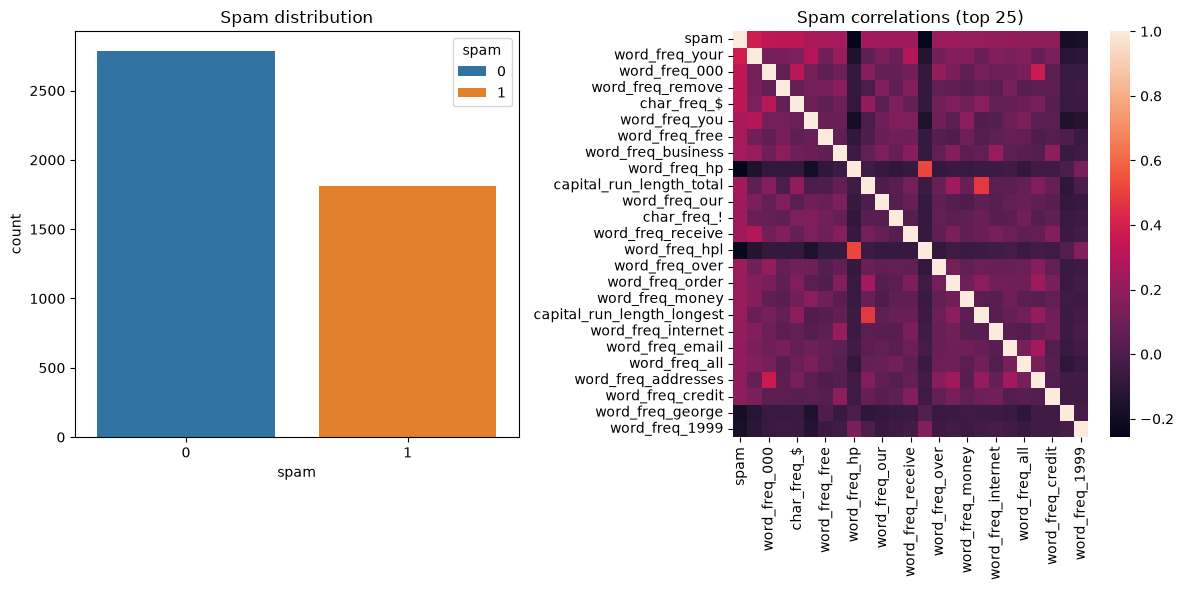

In [24]:
import matplotlib.pyplot as plt 
import seaborn as sns

spam_column = 'spam'

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# df["spam"].value_counts().plot(kind='bar', ax=axs[0], color=['blue', 'orange'])

# spam_counts = df["spam"].value_counts().sort_index()
# axs[0].bar(spam_counts.index, spam_counts.values, color=['blue', 'orange'])

sns.countplot(data=df, x=spam_column, ax=axs[0], hue=spam_column)
axs[0].set_title("Spam distribution")

n_feats = 25
df_corrs = df.corr()
top_spam_corr_feats = df_corrs[spam_column].abs().sort_values(ascending=False).head(n_feats).index 
sns.heatmap(df_corrs.loc[top_spam_corr_feats, top_spam_corr_feats], ax=axs[1], annot=False)
axs[1].set_title(f"Spam correlations (top {n_feats})")
plt.tight_layout()

In [25]:
from sklearn.model_selection import train_test_split

x = df[top_spam_corr_feats].drop(spam_column, axis=1).values 
y = df[spam_column].values

seed = 0 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True, stratify=y, random_state=seed)

n_train = len(x_train)
n_test = len(x_test)

print("n_train:", n_train)
print("n_test:", n_test)

display(x_train)
display(x_test)
display(y_train)
display(y_test)

n_train: 3220
n_test: 1381


array([[0.15, 0.  , 0.  , ..., 0.  , 0.07, 0.47],
       [1.8 , 0.  , 0.  , ..., 0.49, 0.  , 0.  ],
       [0.  , 0.  , 1.66, ..., 0.  , 0.  , 0.  ],
       ...,
       [1.08, 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.71, 0.  , 0.  , ..., 0.  , 0.35, 0.  ],
       [0.55, 0.  , 0.  , ..., 0.  , 0.  , 0.55]], shape=(3220, 24))

array([[0.58, 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.3 , 0.  , 0.3 , ..., 0.  , 0.3 , 0.15],
       ...,
       [1.32, 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.09],
       [2.44, 0.  , 0.27, ..., 0.  , 0.  , 0.  ]], shape=(1381, 24))

array([0, 1, 1, ..., 1, 0, 0], shape=(3220,))

array([1, 0, 0, ..., 1, 0, 1], shape=(1381,))

In [26]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler  # x′ = (x − médian) / IQR, with IQR = Q₃ − Q₁

# scaler = RobustScaler()

preprocess_pipeline = Pipeline([
    # ("imputation", SimpleImputer(strategy="median")),  # filling missing values with the median
    ("scaling", RobustScaler()),
    ])

x_train = preprocess_pipeline.fit_transform(x_train)
x_test = preprocess_pipeline.transform(x_test)

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    solver='saga', # SAGA = Stochastic Average Gradient Accelerated : min_w 1/n∑ f_i(w)+h(w), w^{k+1}=prox_{γh}( w^k -γ[ ∇f_j(w^k)-∇f_j(φ_j^k)+ 1/n∑_i ∇f_i(φ_i^k) ] ) — estimateur de gradient à variance réduite avec mémoire φ_j des derniers gradients
    l1_ratio=0.5,
    C=1,
    max_iter=10000,
    random_state=seed
  ) # P(w) = λ × [l1_ratio × ‖w‖₁ + (1 − l1_ratio) × ‖w‖₂² / 2]

log_model.fit(x_train, y_train)

weights = log_model.coef_
bias = log_model.intercept_

print("weights =", weights)
print("bias =", bias)

weights = [[ 0.33477571  1.7625927   2.47039352  0.27906059  0.11043143  0.10111339
   1.06025832 -1.69495491  0.11774176  0.21639243  0.30465305 -0.23371355
  -0.81494324  0.5065419   0.47517672  0.57589373  0.42252454  0.62641079
   0.27923875  0.06198935  0.47617233  0.83468511 -2.1925721  -0.39390047]]
bias = [-2.04463791]


In [ ]:
from lab import pred_eval

y_train_pred = log_model.predict(x_train)
y_test_pred = log_model.predict(x_test)

y_train_probas = log_model.predict_proba(x_train)[:, 1]
y_test_probas = log_model.predict_proba(x_test)[:, 1]

res_lr_train, axs_lr_train = pred_eval(y_train, y_train_pred, y_train_probas, labels=[0, 1])
res_lr_test, axs_lr_test = pred_eval(y_test, y_test_pred, y_test_probas, labels=[0, 1])

In [29]:
import torch 

if hasattr(torch, 'xpu') and torch.xpu.is_available():
    device = 'xpu'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

print(device)

xpu


In [30]:
from torch.utils.data import TensorDataset, DataLoader

x_train_t = torch.from_numpy(x_train).to(device).float()
x_test_t = torch.from_numpy(x_test).to(device).float()

y_train_t = torch.from_numpy(y_train).unsqueeze(1).to(device).float()
y_test_t = torch.from_numpy(y_test).unsqueeze(1).to(device).float()

display(x_train, x_test, y_train, y_test)

print("x_train_t dtype : ", x_train_t.dtype)
print("y_train_t dtype : ", y_train_t.dtype)
print("x_test_t dtype : ", x_test_t.dtype)
print("y_test_t dtype : ", y_test_t.dtype)

batch_size = 64

train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(x_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

array([[-0.0703125,  0.       ,  0.       , ...,  0.       ,  0.07     ,
         0.47     ],
       [ 1.21875  ,  0.       ,  0.       , ...,  0.49     ,  0.       ,
         0.       ],
       [-0.1875   ,  0.       ,  1.66     , ...,  0.       ,  0.       ,
         0.       ],
       ...,
       [ 0.65625  ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.3671875,  0.       ,  0.       , ...,  0.       ,  0.35     ,
         0.       ],
       [ 0.2421875,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.55     ]], shape=(3220, 24))

array([[ 0.265625,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [-0.1875  ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.046875,  0.      ,  0.3     , ...,  0.      ,  0.3     ,
         0.15    ],
       ...,
       [ 0.84375 ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [-0.1875  ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.09    ],
       [ 1.71875 ,  0.      ,  0.27    , ...,  0.      ,  0.      ,
         0.      ]], shape=(1381, 24))

array([0, 1, 1, ..., 1, 0, 0], shape=(3220,))

array([1, 0, 0, ..., 1, 0, 1], shape=(1381,))

x_train_t dtype :  torch.float32
y_train_t dtype :  torch.float32
x_test_t dtype :  torch.float32
y_test_t dtype :  torch.float32


In [31]:
import torch.nn as nn
import copy

n_in = x_train_t.shape[1]
n_hiddens = [64, 32, 16]
n_out = 1
print("n_in:", n_in)
print("n_hiddens:", n_hiddens)
print("n_out:", n_out)

# mlp_model = nn.Sequential(
#     nn.Linear(n_in, n_hiddens[0]),
#     nn.ReLU(),
#     nn.Dropout(0.3),
#     nn.Linear(n_hiddens[0], n_hiddens[1]),
#     nn.ReLU(),
#     nn.Dropout(0.3),
#     nn.Linear(n_hiddens[1], n_hiddens[2]),
#     nn.ReLU(),
#     nn.Linear(n_hiddens[2], n_out),
#     # nn.Softmax(n_out),
#     nn.Sigmoid(),
# )

class SpamClassifier(nn.Module):
    def __init__(self, n_in, n_hiddens = [64, 32, 16], n_out=1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_in, n_hiddens[0]),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_hiddens[0], n_hiddens[1]),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_hiddens[1], n_hiddens[2]),
            nn.ReLU(),
            nn.Linear(n_hiddens[2], n_out),
            # nn.Softmax(n_out),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x)

mlp_model = SpamClassifier(n_in, n_hiddens, n_out)
mlp_model.to(device).float()
state = copy.deepcopy(mlp_model.state_dict())

display(mlp_model)
display(state)
display([param.shape for param in mlp_model.parameters()])

n_in: 24
n_hiddens: [64, 32, 16]
n_out: 1


SpamClassifier(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

OrderedDict([('network.0.weight',
              tensor([[-0.0727, -0.1291,  0.1271,  ..., -0.0132, -0.1151,  0.0965],
                      [-0.0866, -0.0280,  0.0953,  ..., -0.0140,  0.0745,  0.0897],
                      [ 0.1139, -0.0151, -0.0961,  ...,  0.0344, -0.2041,  0.1595],
                      ...,
                      [-0.1555,  0.0870, -0.1046,  ..., -0.1576,  0.1330, -0.1749],
                      [ 0.1532, -0.1695,  0.1867,  ..., -0.1961,  0.1453, -0.0277],
                      [-0.1372, -0.2030, -0.1081,  ...,  0.1417, -0.0288, -0.2012]],
                     device='xpu:0')),
             ('network.0.bias',
              tensor([ 0.1943, -0.1069, -0.1763,  0.0964, -0.0688, -0.0984,  0.0935,  0.0215,
                      -0.0819,  0.0030,  0.1779,  0.0954, -0.1402, -0.0035,  0.1941,  0.1131,
                      -0.0934, -0.0322, -0.0127, -0.1933, -0.0078, -0.1117,  0.2026, -0.1305,
                       0.1866, -0.1800, -0.0186,  0.1579, -0.0330, -0.0921,  0.00

[torch.Size([64, 24]),
 torch.Size([64]),
 torch.Size([32, 64]),
 torch.Size([32]),
 torch.Size([16, 32]),
 torch.Size([16]),
 torch.Size([1, 16]),
 torch.Size([1])]

## 5. Training

[Epoch 1/20] Train loss: 0.6147739057447396 | Train acc: 0.7947204968944099
[Epoch 2/20] Train loss: 0.42437097430229187 | Train acc: 0.8804347826086957
[Epoch 3/20] Train loss: 0.35166000034294875 | Train acc: 0.9006211180124224
[Epoch 4/20] Train loss: 0.31485475278368186 | Train acc: 0.90527950310559
[Epoch 5/20] Train loss: 0.2492129715049968 | Train acc: 0.9152173913043479
[Epoch 6/20] Train loss: 0.23483173666047116 | Train acc: 0.9177018633540373
[Epoch 7/20] Train loss: 0.23415967047798866 | Train acc: 0.9195652173913044
[Epoch 8/20] Train loss: 0.2279537032340087 | Train acc: 0.9211180124223602
[Epoch 9/20] Train loss: 0.21878523394173266 | Train acc: 0.9229813664596274
[Epoch 10/20] Train loss: 0.2177030344804128 | Train acc: 0.9211180124223602
[Epoch 11/20] Train loss: 0.21804285122483386 | Train acc: 0.922360248447205
[Epoch 12/20] Train loss: 0.21336791941932604 | Train acc: 0.9217391304347826
[Epoch 13/20] Train loss: 0.2115720666798891 | Train acc: 0.9251552795031056
[Ep

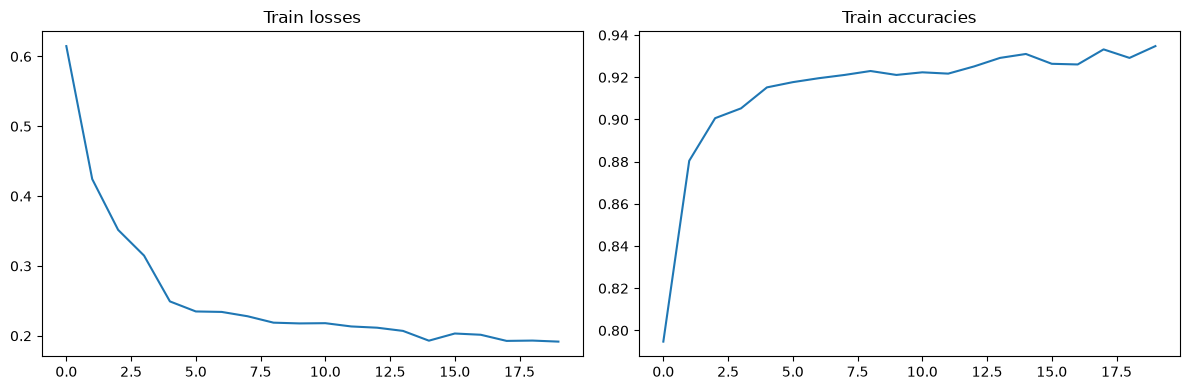

In [32]:
mlp_model.load_state_dict(state)
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, betas=(0.9, 0.999), weight_decay=1e-2)

train_losses = []
train_accs = []
test_losses = []
test_accs = []

epochs = 20
for epoch in range(epochs):
    mlp_model.train() # For reactivating things like dropout, batchnorm ..
    epoch_loss = 0
    correct = 0

    for x_batch, y_batch in train_loader:
        outputs = mlp_model(x_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            epoch_loss += loss.item()
            predicted = (outputs >= 0.5).float()
            correct += (predicted == y_batch).sum().item()

    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)
    train_acc = correct / n_train
    train_accs.append(train_acc)
    print(f"[Epoch {epoch+1}/{epochs}] Train loss: {train_loss} | Train acc: {train_acc}")

fig, axs = plt.subplots(1, 2, figsize=(12,4))

axs[0].plot(train_losses)
axs[0].set_title("Train losses")
axs[1].plot(train_accs)
axs[1].set_title("Train accuracies")
plt.tight_layout()

In [ ]:
mlp_model.eval()
with torch.no_grad():
    y_train_probas = mlp_model(x_train_t).cpu().numpy()
    y_test_probas = mlp_model(x_test_t).cpu().numpy()

y_train_pred = y_train_probas >= 0.5
y_test_pred = y_test_probas >= 0.5

res_mlp_train, axs_mlp_train = pred_eval(y_train, y_train_pred, y_train_probas, labels=[0, 1])
res_mlp_test, axs_mlp_test = pred_eval(y_test, y_test_pred, y_test_probas, labels=[0, 1])

In [ ]:
model_path = Context.resolve("assets", "results", "spam_classifier.pt")
torch.save(mlp_model.state_dict(), model_path)

In [35]:
state = torch.load(model_path)
mlp_model.load_state_dict(state)
mlp_model.eval()

with torch.no_grad():
    sample = x_test_t[:5]
    probas = mlp_model(sample).cpu().numpy()

preds = (probas >= 0.5)

pred_label = lambda y: "Spam" if y == 1 else "Ham"
pred_conf = lambda proba: proba if proba >= 0.5 else 1 - proba

print("Predictions")
for i, (pred, proba) in enumerate(zip(preds, probas)):
    print(f"Ex {i+1}: {pred_label(pred)} (confidence: {pred_conf(proba)})")

Predictions
Ex 1: Spam (confidence: [0.7204145])
Ex 2: Ham (confidence: [0.9647791])
Ex 3: Ham (confidence: [0.9868009])
Ex 4: Ham (confidence: [0.9820711])
Ex 5: Spam (confidence: [0.990099])
